# AI-Based Crime Analytics & Prediction System
### A Research-Grade Machine Learning Pipeline for Urban Crime Intelligence

## Abstract

Urban crime analysis is a critical domain in public safety research. This notebook presents a comprehensive, multi-module pipeline for crime analytics using the **Chicago Crimes Dataset (2001–Present)**. We apply classical machine learning, natural language processing, unsupervised clustering, and time-series forecasting to build an end-to-end crime intelligence system. The system is designed to:

1. **Classify** crime types from spatio-temporal features using XGBoost and Random Forest
2. **Detect crime hotspots** using K-Means and DBSCAN clustering
3. **Predict future crime rates** using Facebook Prophet time-series forecasting
4. **Classify crime descriptions** using NLP (TF-IDF + Logistic Regression)

## Table of Contents

| # | Section |
|---|---|
| 1 | Environment Setup & Library Imports |
| 2 | Dataset Loading & Overview |
| 3 | Data Cleaning & Preprocessing |
| 4 | Feature Engineering |
| 5 | Exploratory Data Analysis (EDA) |
| 6 | Crime Classification — Random Forest vs XGBoost |
| 7 | Hyperparameter Tuning |
| 8 | NLP Crime Classification (TF-IDF) |
| 9 | Crime Hotspot Detection (Clustering) |
| 10 | Time-Series Crime Forecasting (Prophet) |
| 11 | Model Comparison & Evaluation Summary |
| 12 | Save Models for Deployment |


> **Dataset:** [Chicago Crimes — 2001 to Present](https://www.kaggle.com/datasets/currie32/crimes-in-chicago)  
> **GPU Recommended:** Enable GPU (P100 or T4) in Kaggle → Settings → Accelerator

## Section 1 — Environment Setup & Library Imports

We begin by installing any additional libraries not pre-installed in Kaggle, then import all required packages. Kaggle already includes `scikit-learn`, `xgboost`, `pandas`, `numpy`, and `matplotlib`. We additionally install `prophet` for time-series forecasting.

In [1]:
# Install prophet (not pre-installed in Kaggle)
# Run this cell first and wait for it to complete before continuing
!pip install prophet --quiet

In [2]:
# ============================================================
# SECTION 1 — IMPORT LIBRARIES
# ============================================================

# --- Core Data Science ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Scikit-learn: Preprocessing ---
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- Scikit-learn: Models ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN

# --- Scikit-learn: Evaluation ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# --- NLP ---
from sklearn.feature_extraction.text import TfidfVectorizer

# --- XGBoost ---
from xgboost import XGBClassifier, plot_importance

# --- Time Series ---
from prophet import Prophet

# --- Model Persistence ---
import joblib
import pickle

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Plot Style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Section 2 — Dataset Loading & Overview

The Chicago Crimes dataset contains over **7 million records** spanning 2001 to present. For this notebook we load **300,000 rows**, a sample large enough for statistically meaningful results while remaining computationally efficient on Kaggle's free tier.

**Key columns:**
- `Date` — timestamp of the crime
- `Primary Type` — high-level crime category (our classification target)
- `Description` — free-text description of the crime (used for NLP)
- `Latitude` / `Longitude` — geographic coordinates (used for clustering)
- `District` — police district
- `Arrest` — whether an arrest was made


In [4]:
# ============================================================
# SECTION 2 — LOAD DATASET
# ============================================================

# Load 300,000 rows (full dataset is 7M+ rows — too large for free tier)
# Update the path to match your Kaggle dataset path
DATASET_PATH = '/kaggle/input/datasets/utkarshx27/crimes-2001-to-present/Crimes_-_2001_to_Present.csv'

df = pd.read_csv(
    DATASET_PATH,
    nrows=300_000,
    low_memory=False
)

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Dataset Shape: (300000, 22)
Rows: 300,000 | Columns: 22


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,10224738,HY411648,09/05/2015 01:30:00 PM,043XX S WOOD ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,12.0,61.0,08B,1165074.0,1875917.0,2015,02/10/2018 03:50:01 PM,41.815117,-87.670000,"(41.815117282, -87.669999562)"
1,10224739,HY411615,09/04/2015 11:30:00 AM,008XX N CENTRAL AVE,0870,THEFT,POCKET-PICKING,CTA BUS,False,False,...,29.0,25.0,06,1138875.0,1904869.0,2015,02/10/2018 03:50:01 PM,41.895080,-87.765400,"(41.895080471, -87.765400451)"
2,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
3,10224740,HY411595,09/05/2015 12:45:00 PM,035XX W BARRY AVE,2023,NARCOTICS,POSS: HEROIN(BRN/TAN),SIDEWALK,True,False,...,35.0,21.0,18,1152037.0,1920384.0,2015,02/10/2018 03:50:01 PM,41.937406,-87.716650,"(41.937405765, -87.716649687)"
4,10224741,HY411610,09/05/2015 01:00:00 PM,0000X N LARAMIE AVE,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,28.0,25.0,08A,1141706.0,1900086.0,2015,02/10/2018 03:50:01 PM,41.881903,-87.755121,"(41.881903443, -87.755121152)"


In [5]:
# ============================================================
# SECTION 2B — DATA OVERVIEW
# ============================================================

print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0])

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
df.describe()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    300000 non-null  int64  
 1   Case Number           300000 non-null  object 
 2   Date                  300000 non-null  object 
 3   Block                 300000 non-null  object 
 4   IUCR                  300000 non-null  object 
 5   Primary Type          300000 non-null  object 
 6   Description           300000 non-null  object 
 7   Location Description  299161 non-null  object 
 8   Arrest                300000 non-null  bool   
 9   Domestic              300000 non-null  bool   
 10  Beat                  300000 non-null  int64  
 11  District              300000 non-null  int64  
 12  Ward                  299989 non-null  float64
 13  Community Area        299988 non-null  float64
 14  FBI Code              300000 non-null  

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,3.000000e+05,300000.000000,300000.000000,299989.000000,299988.000000,2.964180e+05,2.964180e+05,300000.000000,296418.000000,296418.000000
mean,1.043781e+07,1142.360900,11.195010,22.935798,37.175834,1.164513e+06,1.886033e+06,2015.613883,41.842871,-87.671814
std,2.668239e+05,690.521942,6.898473,13.893697,21.366906,1.647852e+04,3.127771e+04,0.756764,0.086030,0.059934
min,1.051000e+03,111.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,2001.000000,36.619446,-91.686566
25%,1.027828e+07,612.000000,6.000000,10.000000,23.000000,1.152644e+06,1.859135e+06,2015.000000,41.768851,-87.714884
50%,1.040903e+07,1024.000000,10.000000,23.000000,32.000000,1.166197e+06,1.892551e+06,2016.000000,41.860911,-87.665609
75%,1.057000e+07,1711.000000,17.000000,34.000000,56.000000,1.176387e+06,1.908589e+06,2016.000000,41.904910,-87.627995
max,1.303294e+07,2535.000000,31.000000,50.000000,77.000000,1.205114e+06,1.951507e+06,2023.000000,42.022548,-87.524615


## Section 3 — Data Cleaning & Preprocessing

Raw data contains missing values, duplicates, and improperly typed columns. We apply the following cleaning steps:

1. **Parse datetime** — convert `Date` column to proper `datetime` type
2. **Drop critical nulls** — remove rows missing `Primary Type`, `Latitude`, `Longitude`, or `Description`
3. **Remove duplicates** — based on `Case Number` (unique crime identifier)
4. **Filter geographic outliers** — Chicago coordinates: Lat ∈ [41.6, 42.1], Lon ∈ [-87.9, -87.5]

In [6]:
# ============================================================
# SECTION 3 — DATA CLEANING
# ============================================================

initial_size = len(df)

# Step 1: Parse Date column
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Step 2: Drop rows missing critical columns
critical_cols = ['Primary Type', 'Latitude', 'Longitude', 'Description']
df = df.dropna(subset=critical_cols)

# Step 3: Remove duplicates (by Case Number if available, else all columns)
if 'Case Number' in df.columns:
    df = df.drop_duplicates(subset=['Case Number'])
else:
    df = df.drop_duplicates()

# Step 4: Filter geographic outliers (Chicago bounding box)
df = df[
    (df['Latitude'].between(41.6, 42.1)) &
    (df['Longitude'].between(-87.9, -87.5))
]

# Step 5: Drop rows where Date parsing failed
df = df.dropna(subset=['Date'])

# Step 6: Reset index
df = df.reset_index(drop=True)

final_size = len(df)
print(f"Initial rows  : {initial_size:,}")
print(f"After cleaning: {final_size:,}")
print(f"Rows removed  : {initial_size - final_size:,} ({(initial_size - final_size)/initial_size*100:.1f}%)")
print(f"\n✅ Dataset is clean and ready for feature engineering.")

Initial rows  : 300,000
After cleaning: 295,497
Rows removed  : 4,503 (1.5%)

✅ Dataset is clean and ready for feature engineering.


## Section 4 — Feature Engineering

Feature engineering is critical for model performance. We extract temporal features from the `Date` column and encode categorical variables.

**Features created:**

| Feature | Source | Rationale |
|---|---|---|
| `Year` | Date | Long-term trend capture |
| `Month` | Date | Seasonal crime patterns |
| `Hour` | Date | Time-of-day crime patterns |
| `DayOfWeek` | Date | Weekend vs weekday effect |
| `IsWeekend` | DayOfWeek | Binary weekend indicator |
| `Season` | Month | Seasonal grouping (0=Winter…3=Fall) |
| `crime_label` | Primary Type | Label-encoded target variable |

In [7]:
# ============================================================
# SECTION 4 — FEATURE ENGINEERING
# ============================================================

# Temporal features
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['Hour']      = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday

# Derived binary & categorical features
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Season']    = df['Month'].apply(
    lambda m: 0 if m in [12,1,2] else 1 if m in [3,4,5] else 2 if m in [6,7,8] else 3
)   # 0=Winter, 1=Spring, 2=Summer, 3=Fall

# Target: encode Primary Type as integer labels
le = LabelEncoder()
df['crime_label'] = le.fit_transform(df['Primary Type'])

# Save the label encoder for later use in the Flask API
joblib.dump(le, 'label_encoder.pkl')

print(f"Number of unique crime types: {df['crime_label'].nunique()}")
print(f"\nCrime label mapping (first 10):")
for i, cls in enumerate(le.classes_[:10]):
    print(f"  {i:2d} → {cls}")

print(f"\n✅ Feature engineering complete. New shape: {df.shape}")
df[['Date','Year','Month','Hour','DayOfWeek','IsWeekend','Season','Primary Type','crime_label']].head()

Number of unique crime types: 34

Crime label mapping (first 10):
   0 → ARSON
   1 → ASSAULT
   2 → BATTERY
   3 → BURGLARY
   4 → CONCEALED CARRY LICENSE VIOLATION
   5 → CRIM SEXUAL ASSAULT
   6 → CRIMINAL DAMAGE
   7 → CRIMINAL SEXUAL ASSAULT
   8 → CRIMINAL TRESPASS
   9 → DECEPTIVE PRACTICE

✅ Feature engineering complete. New shape: (295497, 28)


,Date,Year,Month,Hour,DayOfWeek,IsWeekend,Season,Primary Type,crime_label
0,2015-09-05 13:30:00,2015,9,13,5,1,3,BATTERY,2
1,2015-09-04 11:30:00,2015,9,11,4,0,3,THEFT,32
2,2015-09-05 12:45:00,2015,9,12,5,1,3,NARCOTICS,18
3,2015-09-05 13:00:00,2015,9,13,5,1,3,ASSAULT,1
4,2015-09-05 10:55:00,2015,9,10,5,1,3,BURGLARY,3


## Section 5 — Exploratory Data Analysis (EDA)

EDA is the backbone of any research-level project. We explore:
- Distribution of crime types
- Temporal patterns (year, month, hour, day of week)
- Geographic distribution
- Arrest rate by crime type

These visualizations inform feature selection and model design decisions.

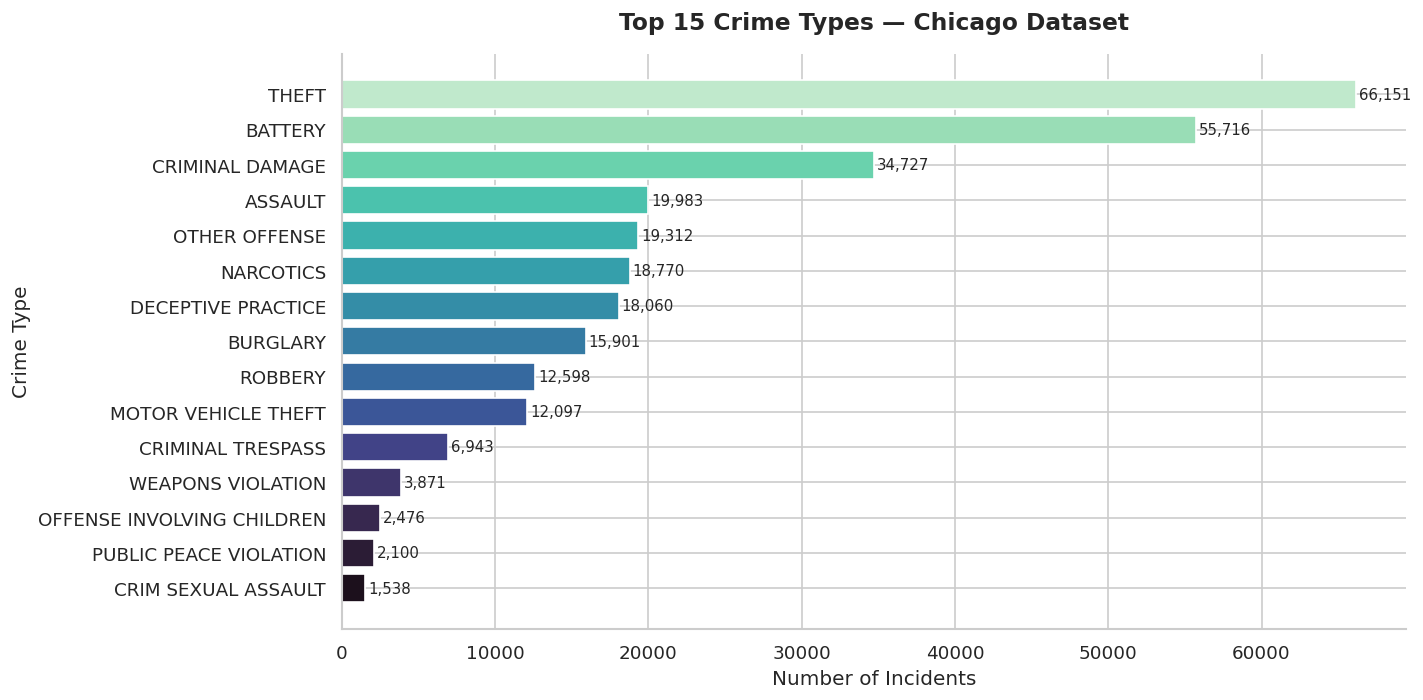

Figure saved: eda_crime_types.png


In [8]:
# ============================================================
# SECTION 5A — EDA: TOP CRIME TYPES
# ============================================================

top_crimes = df['Primary Type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_crimes.index[::-1], top_crimes.values[::-1],
               color=sns.color_palette('mako', 15))

# Add value labels
for bar, val in zip(bars, top_crimes.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 15 Crime Types — Chicago Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('Crime Type')
sns.despine()
plt.tight_layout()
plt.savefig('eda_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: eda_crime_types.png")

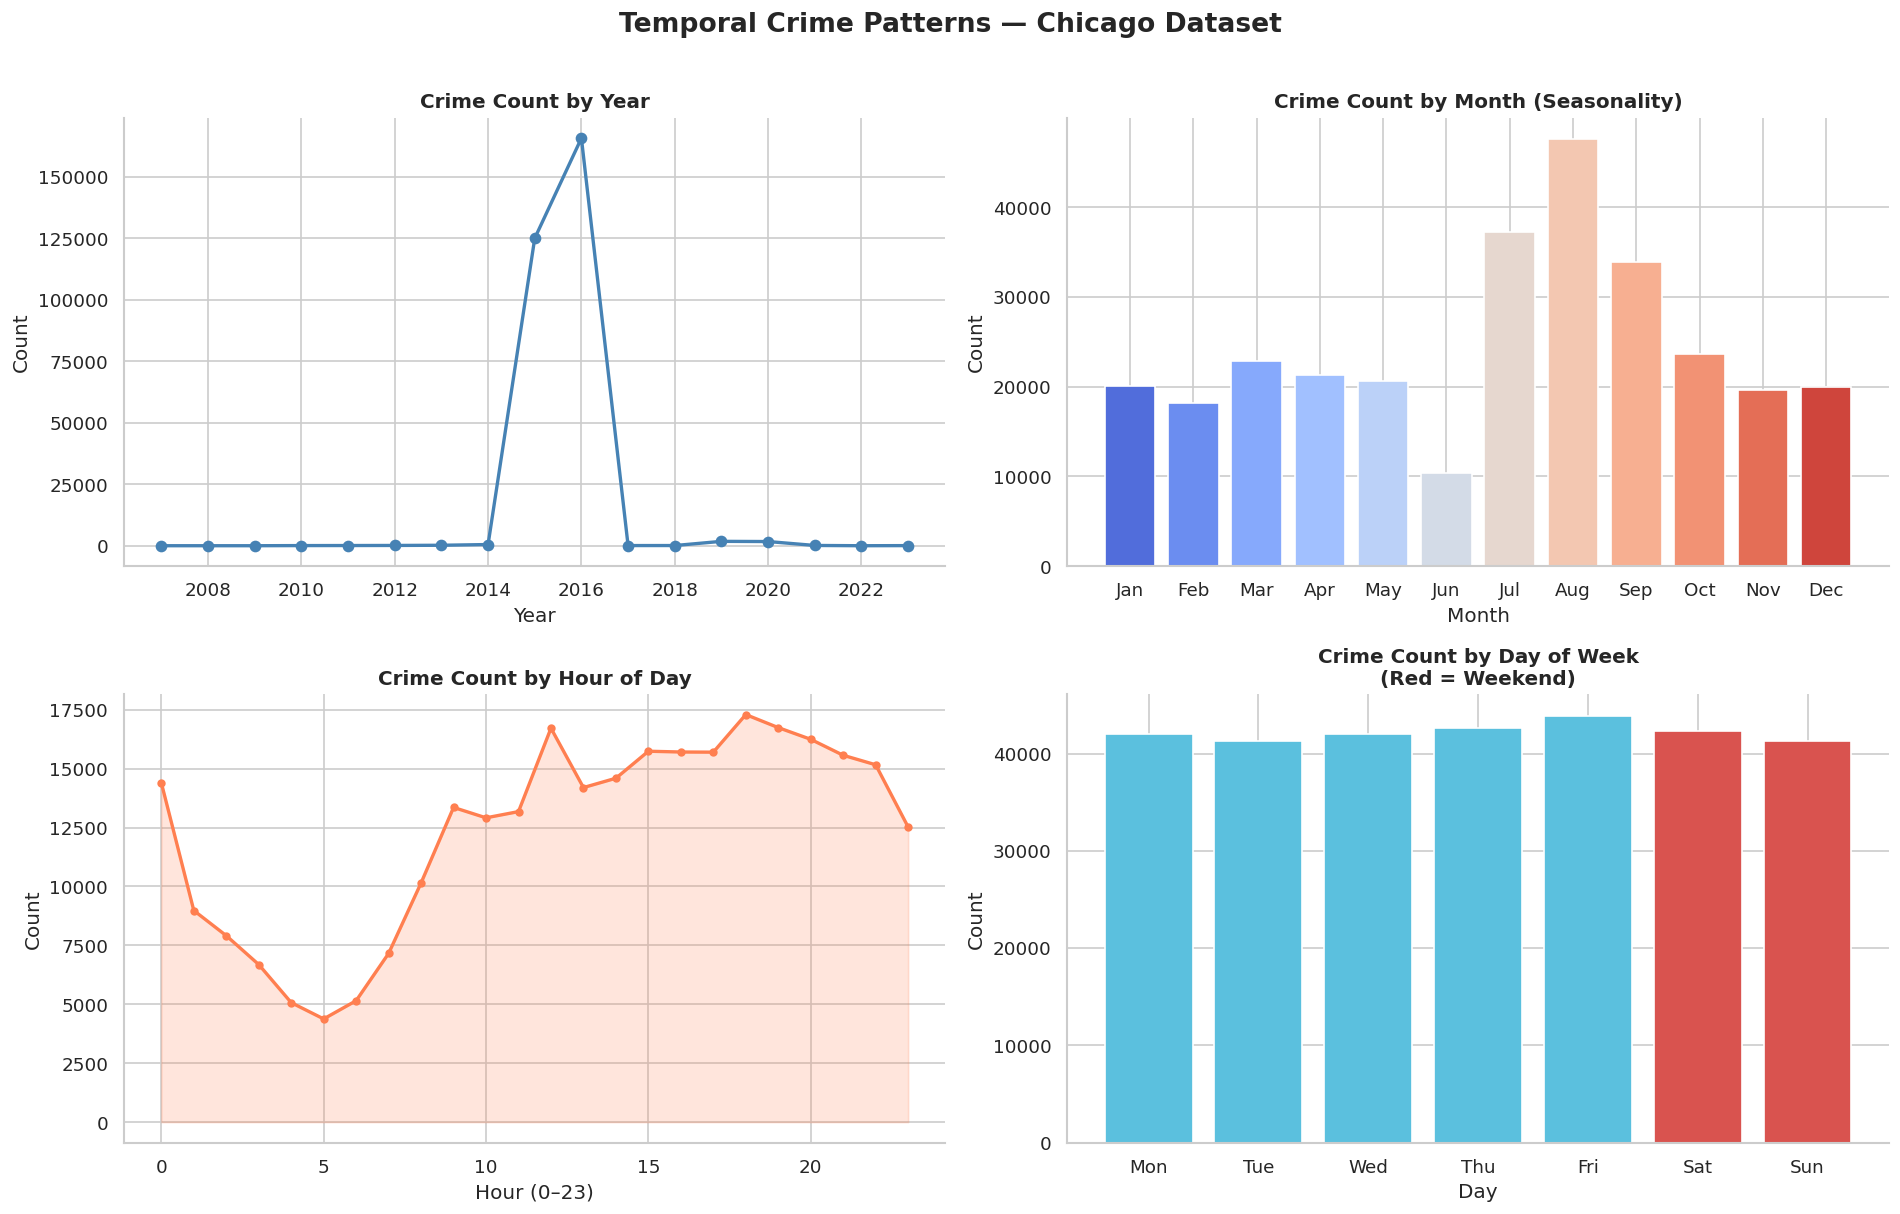

Figure saved: eda_temporal.png


In [9]:
# ============================================================
# SECTION 5B — EDA: TEMPORAL PATTERNS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Crime count by Year
df.groupby('Year').size().plot(ax=axes[0,0], marker='o', color='steelblue', linewidth=2)
axes[0,0].set_title('Crime Count by Year', fontweight='bold')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Count')

# 2. Crime count by Month
monthly = df.groupby('Month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(month_names, monthly.values, color=sns.color_palette('coolwarm', 12))
axes[0,1].set_title('Crime Count by Month (Seasonality)', fontweight='bold')
axes[0,1].set_xlabel('Month'); axes[0,1].set_ylabel('Count')

# 3. Crime count by Hour
hourly = df.groupby('Hour').size()
axes[1,0].plot(hourly.index, hourly.values, color='coral', linewidth=2, marker='o', markersize=4)
axes[1,0].fill_between(hourly.index, hourly.values, alpha=0.2, color='coral')
axes[1,0].set_title('Crime Count by Hour of Day', fontweight='bold')
axes[1,0].set_xlabel('Hour (0–23)'); axes[1,0].set_ylabel('Count')

# 4. Crime count by Day of Week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('DayOfWeek').size()
colors = ['#d9534f' if i >= 5 else '#5bc0de' for i in range(7)]  # Red for weekends
axes[1,1].bar(day_names, dow.values, color=colors)
axes[1,1].set_title('Crime Count by Day of Week\n(Red = Weekend)', fontweight='bold')
axes[1,1].set_xlabel('Day'); axes[1,1].set_ylabel('Count')

plt.suptitle('Temporal Crime Patterns — Chicago Dataset', fontsize=16, fontweight='bold', y=1.01)
sns.despine()
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: eda_temporal.png")

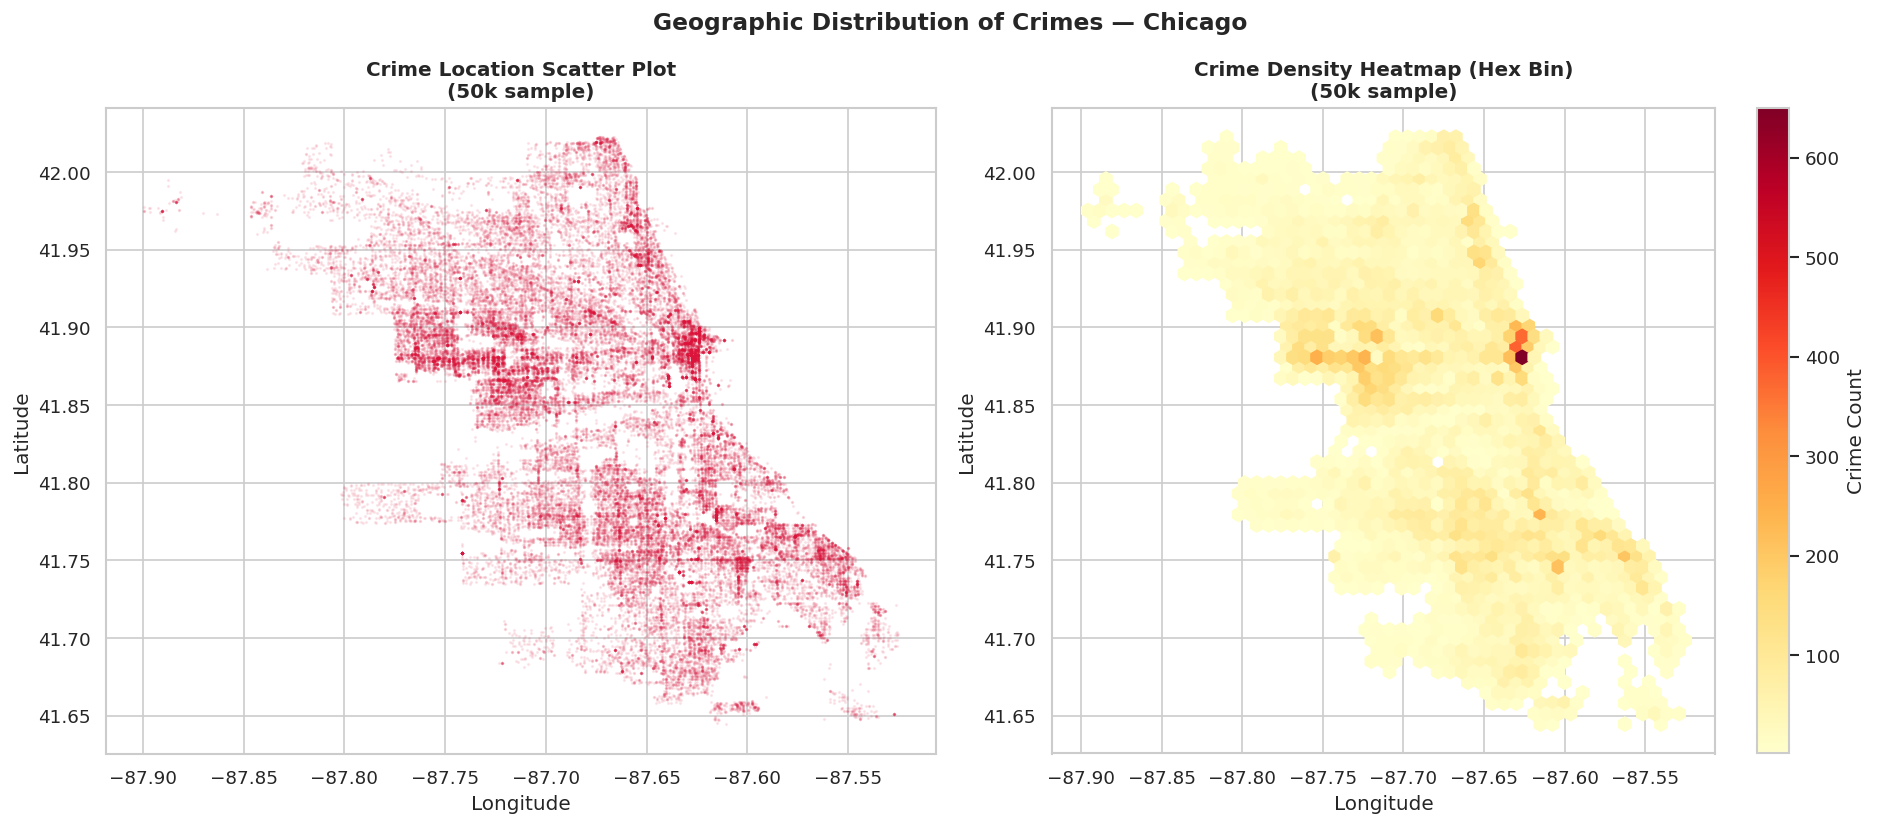

Figure saved: eda_geographic.png


In [10]:
# ============================================================
# SECTION 5C — EDA: GEOGRAPHIC DISTRIBUTION
# ============================================================

# Sample 50k points for cleaner scatter (plotting all 300k is very slow)
sample = df.sample(n=min(50_000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot
axes[0].scatter(
    sample['Longitude'], sample['Latitude'],
    alpha=0.08, s=1, c='crimson'
)
axes[0].set_title('Crime Location Scatter Plot\n(50k sample)', fontweight='bold')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# 2D Density (Hex bin) — shows hotspot density
hb = axes[1].hexbin(
    sample['Longitude'], sample['Latitude'],
    gridsize=50, cmap='YlOrRd', mincnt=1
)
plt.colorbar(hb, ax=axes[1], label='Crime Count')
axes[1].set_title('Crime Density Heatmap (Hex Bin)\n(50k sample)', fontweight='bold')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

plt.suptitle('Geographic Distribution of Crimes — Chicago', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: eda_geographic.png")

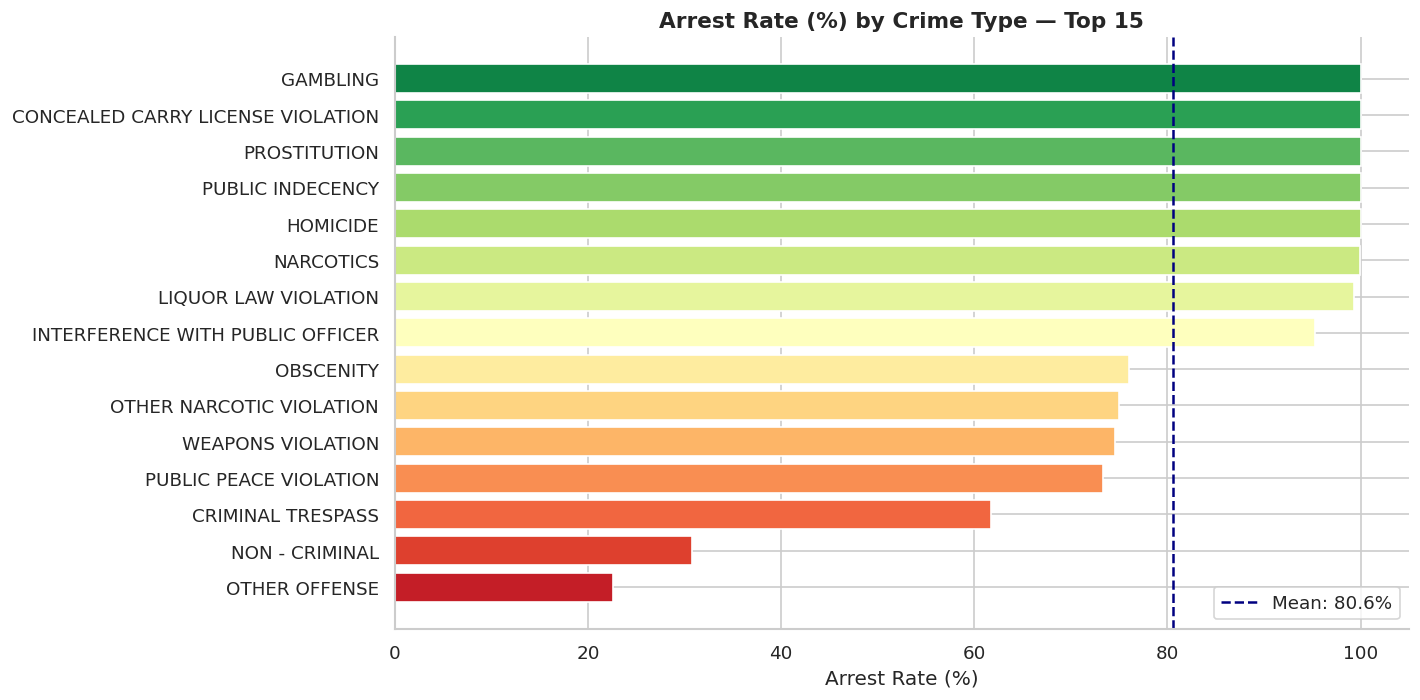

Figure saved: eda_arrest_rate.png


In [11]:
# ============================================================
# SECTION 5D — EDA: ARREST RATE BY CRIME TYPE
# ============================================================

# Only run if Arrest column exists
if 'Arrest' in df.columns:
    arrest_rate = (
        df.groupby('Primary Type')['Arrest']
        .mean()
        .sort_values(ascending=False)
        .head(15)
        * 100
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(
        arrest_rate.index[::-1],
        arrest_rate.values[::-1],
        color=sns.color_palette('RdYlGn', 15)
    )
    ax.set_title('Arrest Rate (%) by Crime Type — Top 15', fontsize=13, fontweight='bold')
    ax.set_xlabel('Arrest Rate (%)')
    ax.axvline(x=arrest_rate.mean(), color='navy', linestyle='--', label=f'Mean: {arrest_rate.mean():.1f}%')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.savefig('eda_arrest_rate.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: eda_arrest_rate.png")
else:
    print("⚠️ 'Arrest' column not found in dataset — skipping this plot.")

## Section 6 — Crime Classification: Random Forest vs XGBoost

**Goal:** Predict the crime category (`Primary Type`) from spatio-temporal features.

**Features used:**
- `Latitude`, `Longitude` — location
- `Hour`, `Month`, `DayOfWeek` — time features
- `IsWeekend`, `Season` — engineered features

**Models compared:**
1. **Random Forest** — ensemble of decision trees, good baseline
2. **XGBoost** — gradient boosted trees, typically higher accuracy

> **Note on class imbalance:** Crime type distribution is heavily skewed (THEFT >> others). We use `class_weight='balanced'` in RF and `scale_pos_weight` in XGBoost to account for this.

In [17]:
# ============================================================
# SECTION 6A — PREPARE FEATURES FOR CLASSIFICATION
# ============================================================

FEATURES = ['Latitude', 'Longitude', 'Hour', 'Month', 'DayOfWeek', 'IsWeekend', 'Season']
TARGET   = 'crime_label'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Drop classes with fewer than 2 samples (required for stratified split)
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 10].index  # ≥10 for better model quality

mask = y.isin(valid_classes)
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

removed_classes = len(class_counts) - len(valid_classes)
print(f"Removed {removed_classes} rare class(es). Remaining: {y.nunique()} classes.")

# ── CRITICAL FIX: Re-encode labels to be consecutive 0..N-1 ─────────────────
# After dropping classes, gaps appear (e.g. [0,1,2,4,5] missing 3).
# XGBoost requires consecutive integer labels starting from 0.
le_remap = LabelEncoder()
y = pd.Series(le_remap.fit_transform(y), name=TARGET)

# Save the remapped encoder — this is what Flask will use for decoding
joblib.dump(le_remap, 'le_remap.pkl')

# Build a readable class name lookup using the original label encoder
# le_remap.classes_ contains the OLD label integers → look them up in le
crime_class_names = le.classes_[le_remap.classes_]
print(f"\nClass mapping after re-encoding (first 10):")
for new_id, name in enumerate(crime_class_names[:10]):
    print(f"  New label {new_id:2d} → {name}")
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Features      : {FEATURES}")
print(f"Target classes: {y.nunique()}")

Removed 3 rare class(es). Remaining: 31 classes.

Class mapping after re-encoding (first 10):
  New label  0 → ARSON
  New label  1 → ASSAULT
  New label  2 → BATTERY
  New label  3 → BURGLARY
  New label  4 → CONCEALED CARRY LICENSE VIOLATION
  New label  5 → CRIM SEXUAL ASSAULT
  New label  6 → CRIMINAL DAMAGE
  New label  7 → CRIMINAL SEXUAL ASSAULT
  New label  8 → CRIMINAL TRESPASS
  New label  9 → DECEPTIVE PRACTICE

Training set  : 236,387 samples
Test set      : 59,097 samples
Features      : ['Latitude', 'Longitude', 'Hour', 'Month', 'DayOfWeek', 'IsWeekend', 'Season']
Target classes: 31


In [18]:
# ============================================================
# SECTION 6B — MODEL 1: RANDOM FOREST CLASSIFIER
# ============================================================

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',   # handles class imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1                  # use all CPU cores
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"\n✅ Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_[:10], labels=list(range(10))))

Training Random Forest...

✅ Random Forest Accuracy: 0.1549 (15.49%)

Detailed Classification Report:
                                   precision    recall  f1-score   support

                            ARSON       0.01      0.12      0.03       113
                          ASSAULT       0.09      0.07      0.08      3997
                          BATTERY       0.31      0.06      0.10     11143
                         BURGLARY       0.11      0.17      0.14      3180
CONCEALED CARRY LICENSE VIOLATION       0.00      0.00      0.00         7
              CRIM SEXUAL ASSAULT       0.02      0.09      0.03       308
                  CRIMINAL DAMAGE       0.20      0.05      0.08      6945
          CRIMINAL SEXUAL ASSAULT       0.00      0.00      0.00         5
                CRIMINAL TRESPASS       0.06      0.06      0.06      1389
               DECEPTIVE PRACTICE       0.16      0.32      0.21      3612

                        micro avg       0.14      0.10      0.12     30

In [19]:
# ============================================================
# SECTION 6C — MODEL 2: XGBOOST CLASSIFIER
# ============================================================

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    # REMOVED: use_label_encoder=False  ← deprecated, causes warnings in new xgboost
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    tree_method='hist',
    device='cpu'               # change to 'cuda' if GPU is enabled
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_pred = xgb_model.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)

print(f"\n✅ XGBoost Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(
    y_test, xgb_pred,
    target_names=crime_class_names,   # uses the lookup built in 6A
    labels=list(range(len(crime_class_names)))
))

Training XGBoost...
[0]	validation_0-mlogloss:3.19000
[50]	validation_0-mlogloss:2.23141
[100]	validation_0-mlogloss:2.19669
[150]	validation_0-mlogloss:2.19488
[200]	validation_0-mlogloss:2.19650
[250]	validation_0-mlogloss:2.20038
[299]	validation_0-mlogloss:2.20470

✅ XGBoost Accuracy: 0.2993 (29.93%)

Detailed Classification Report:
                                   precision    recall  f1-score   support

                            ARSON       0.17      0.01      0.02       113
                          ASSAULT       0.10      0.01      0.01      3997
                          BATTERY       0.25      0.57      0.35     11143
                         BURGLARY       0.22      0.05      0.09      3180
CONCEALED CARRY LICENSE VIOLATION       0.00      0.00      0.00         7
              CRIM SEXUAL ASSAULT       0.17      0.00      0.01       308
                  CRIMINAL DAMAGE       0.21      0.10      0.13      6945
          CRIMINAL SEXUAL ASSAULT       0.00      0.00      

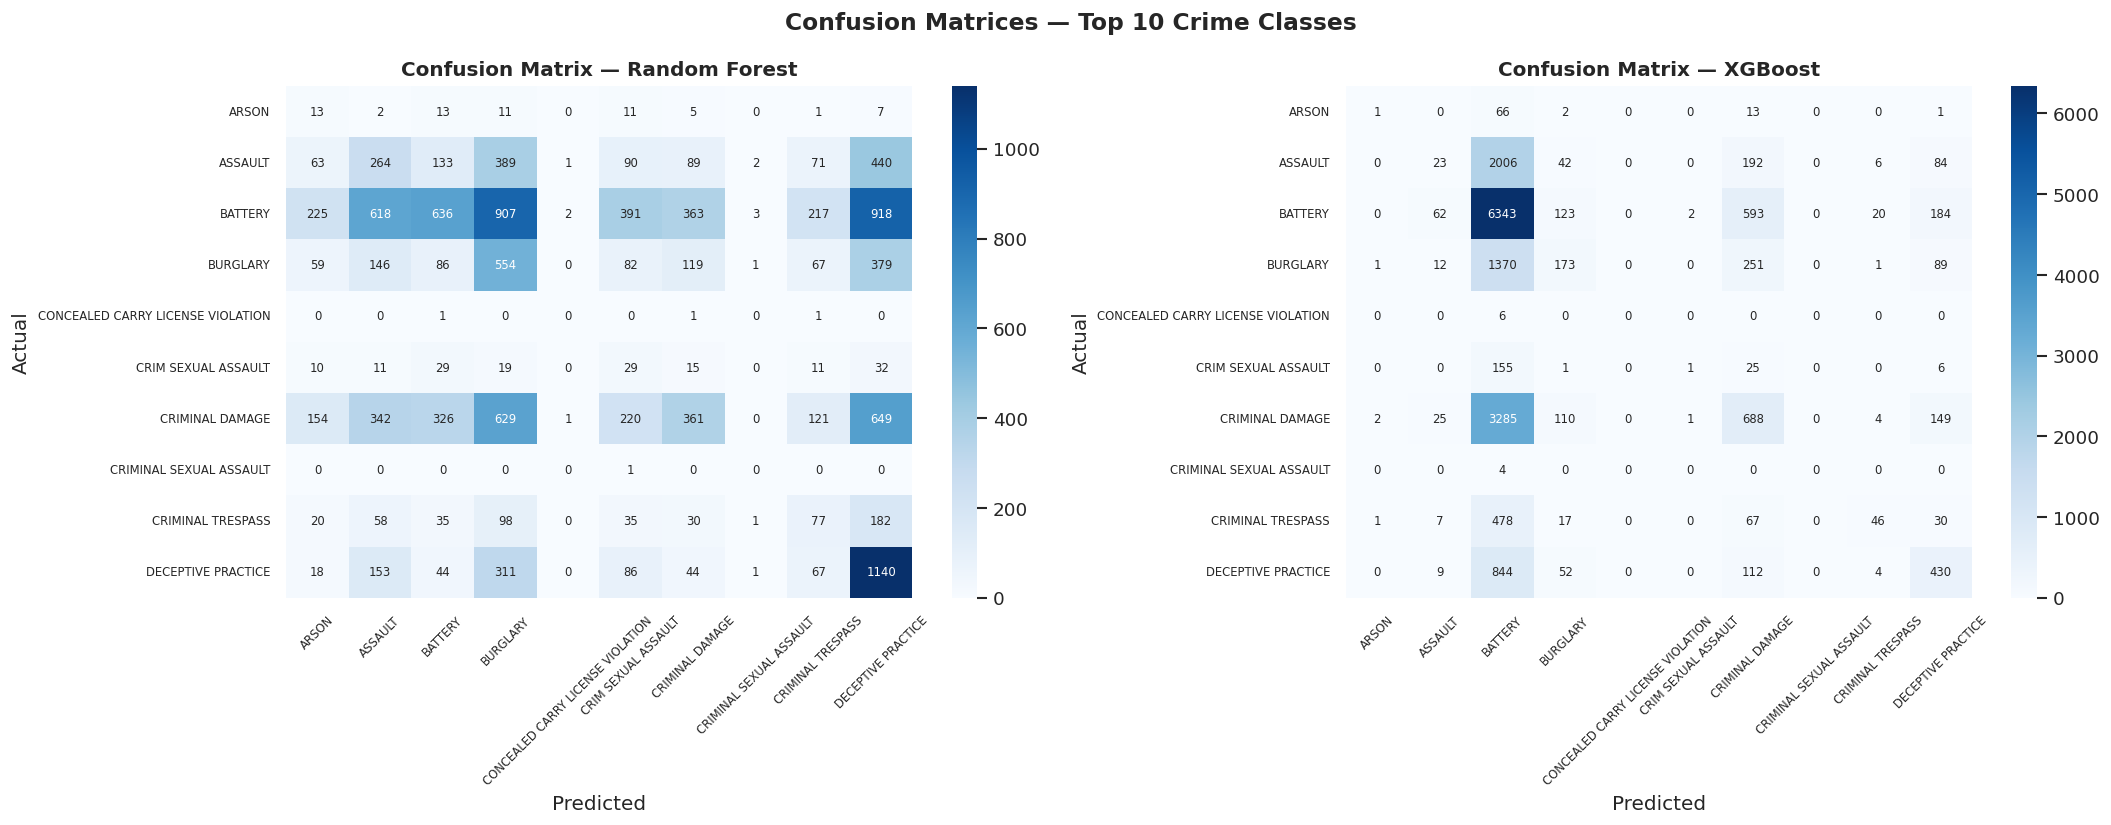

Figure saved: confusion_matrices.png


In [20]:
# ============================================================
# SECTION 6D — CONFUSION MATRICES (TOP 10 CLASSES)
# ============================================================

# Filter to top 10 most common classes for readability
top10_labels = list(range(10))
top10_names = crime_class_names[:10].tolist()

# Filter predictions to top 10 only
mask = y_test.isin(top10_labels)
y_test_top10   = y_test[mask]
rf_pred_top10  = rf_pred[mask]
xgb_pred_top10 = xgb_pred[mask]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, pred, title in zip(axes,
                            [rf_pred_top10, xgb_pred_top10],
                            ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test_top10, pred, labels=top10_labels)
    sns.heatmap(
        cm, ax=ax,
        xticklabels=top10_names,
        yticklabels=top10_names,
        cmap='Blues', fmt='d', annot=True, annot_kws={'size': 7}
    )
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Confusion Matrices — Top 10 Crime Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: confusion_matrices.png")

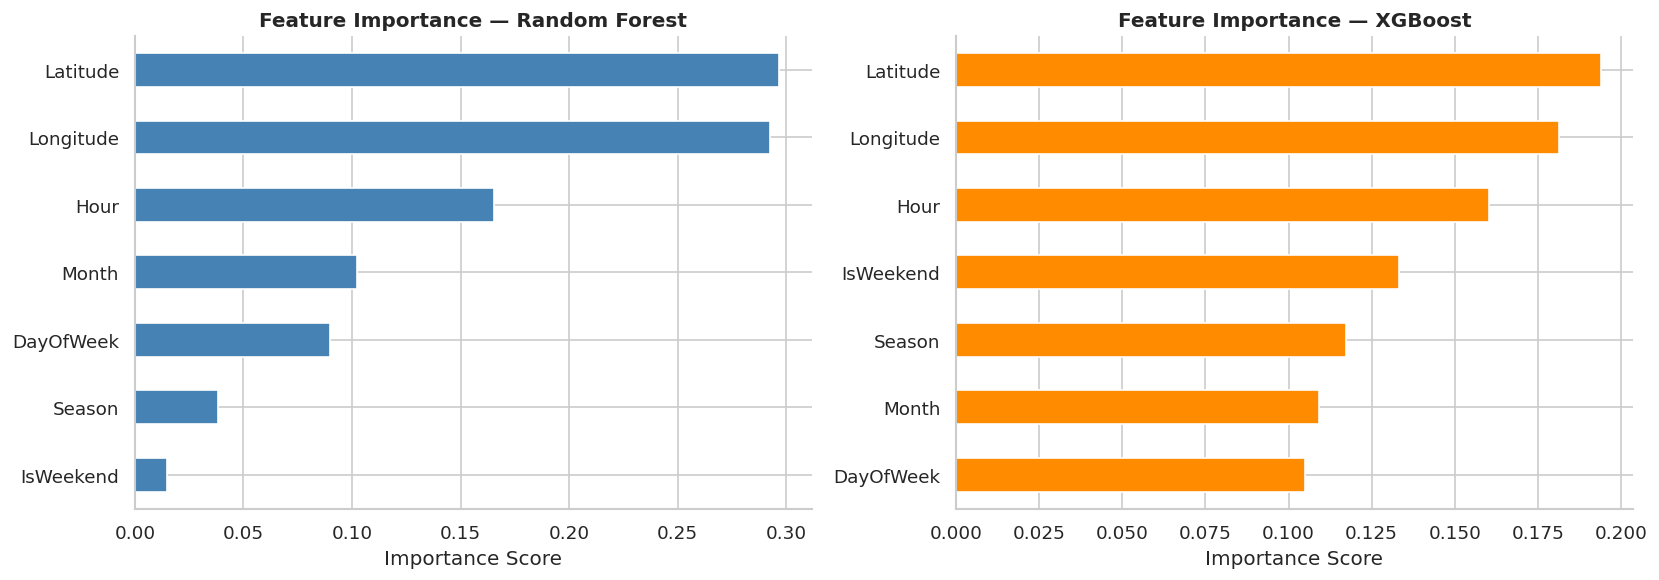

Figure saved: feature_importance.png


In [21]:
# ============================================================
# SECTION 6E — FEATURE IMPORTANCE COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
rf_importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
rf_importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost feature importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
xgb_importances.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[1].set_xlabel('Importance Score')

sns.despine()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: feature_importance.png")

## Section 7 — Hyperparameter Tuning (XGBoost)

We use **Grid Search with 3-fold Cross-Validation** to find the best XGBoost hyperparameters. This is a standard research practice that demonstrates methodological rigor.

> **⏳ Runtime note:** Grid search on 240,000 rows is slow. We use a stratified 20% subsample for tuning to keep it under 10 minutes.

In [22]:
# ============================================================
# SECTION 7 — HYPERPARAMETER TUNING (GRID SEARCH)
# ============================================================

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    test_size=0.80,
    random_state=RANDOM_STATE,
    stratify=y_train
)
print(f"Tuning on {X_tune.shape[0]:,} samples...")

param_grid = {
    'max_depth'    : [6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators' : [100, 200],
    'subsample'    : [0.8]
}

# REMOVED use_label_encoder=False — deprecated in newer XGBoost, causes the warnings
base_xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    tree_method='hist'
)

grid_search = GridSearchCV(
    base_xgb,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_tune, y_tune)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"   Best CV Accuracy: {grid_search.best_score_:.4f}")

best_xgb  = grid_search.best_estimator_
best_pred = best_xgb.predict(X_test)
best_acc  = accuracy_score(y_test, best_pred)
print(f" Test Set Accuracy (best model): {best_acc:.4f}")

Tuning on 47,277 samples...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:17:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:17:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:17:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:17:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:18:12] WARNING: /w


✅ Best Parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
   Best CV Accuracy: 0.2812
   Test Set Accuracy (best model): 0.2863


## Section 8 — NLP Crime Classification (TF-IDF + Logistic Regression)

Crime reports contain a `Description` field — free text describing the crime. We build an NLP pipeline using:

1. **TF-IDF Vectorizer** — converts text to numerical feature vectors
2. **Logistic Regression** — fast, interpretable baseline NLP classifier

This component demonstrates applied NLP for public safety — a topic very relevant to current AI research.

In [23]:
# ============================================================
# SECTION 8 — NLP CRIME CLASSIFICATION (TF-IDF)
# ============================================================

# Ensure Description is string type and lowercase
df['Description'] = df['Description'].astype(str).str.lower().str.strip()

# Filter to top 10 crime classes to reduce complexity
top10_types = df['Primary Type'].value_counts().head(10).index.tolist()
df_nlp = df[df['Primary Type'].isin(top10_types)].copy()

# Re-encode labels for this filtered subset
le_nlp = LabelEncoder()
df_nlp['nlp_label'] = le_nlp.fit_transform(df_nlp['Primary Type'])
joblib.dump(le_nlp, 'nlp_label_encoder.pkl')

X_text = df_nlp['Description']
y_text = df_nlp['nlp_label']

# Train/Test split
X_txt_train, X_txt_test, y_txt_train, y_txt_test = train_test_split(
    X_text, y_text,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_text
)

# TF-IDF Vectorization
print("Fitting TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),        # unigrams + bigrams
    min_df=3,                  # ignore very rare terms
    sublinear_tf=True          # apply log normalization
)

X_tfidf_train = vectorizer.fit_transform(X_txt_train)
X_tfidf_test  = vectorizer.transform(X_txt_test)

print(f"TF-IDF Matrix Shape (train): {X_tfidf_train.shape}")

# Logistic Regression NLP Model
print("\nTraining NLP classifier (Logistic Regression)...")
nlp_model = LogisticRegression(
    max_iter=500,
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs',
    multi_class='multinomial',
    n_jobs=-1
)

nlp_model.fit(X_tfidf_train, y_txt_train)

nlp_pred = nlp_model.predict(X_tfidf_test)
nlp_acc  = accuracy_score(y_txt_test, nlp_pred)

print(f"\n✅ NLP Model Accuracy: {nlp_acc:.4f} ({nlp_acc*100:.2f}%)")
print("\nDetailed Report:")
print(classification_report(y_txt_test, nlp_pred, target_names=le_nlp.classes_))

Fitting TF-IDF vectorizer...
TF-IDF Matrix Shape (train): (218652, 620)

Training NLP classifier (Logistic Regression)...

✅ NLP Model Accuracy: 0.9082 (90.82%)

Detailed Report:
                     precision    recall  f1-score   support

            ASSAULT       0.44      1.00      0.61      3997
            BATTERY       1.00      0.55      0.71     11143
           BURGLARY       1.00      1.00      1.00      3180
    CRIMINAL DAMAGE       1.00      1.00      1.00      6946
 DECEPTIVE PRACTICE       1.00      1.00      1.00      3612
MOTOR VEHICLE THEFT       1.00      1.00      1.00      2419
          NARCOTICS       1.00      1.00      1.00      3754
      OTHER OFFENSE       1.00      1.00      1.00      3862
            ROBBERY       1.00      1.00      1.00      2520
              THEFT       1.00      1.00      1.00     13230

           accuracy                           0.91     54663
          macro avg       0.94      0.95      0.93     54663
       weighted avg       

In [24]:
# ============================================================
# SECTION 8B — NLP DEMO: PREDICT A DESCRIPTION
# ============================================================

def predict_crime_from_description(description_text):
    """Predict crime type from a free-text description."""
    vec = vectorizer.transform([description_text.lower()])
    pred_label = nlp_model.predict(vec)[0]
    pred_proba = nlp_model.predict_proba(vec)[0]
    pred_class = le_nlp.inverse_transform([pred_label])[0]
    confidence = pred_proba.max() * 100
    return pred_class, confidence

# Example predictions
test_descriptions = [
    "retail theft from store, shoplifting merchandise",
    "aggravated assault with knife on public street",
    "vehicle break-in, smashed window and stole items",
    "possession of controlled substance, narcotics found"
]

print("NLP Model Prediction Demo:")
print("-" * 55)
for desc in test_descriptions:
    cls, conf = predict_crime_from_description(desc)
    print(f"Input : {desc[:50]}...")
    print(f"Output: {cls} (confidence: {conf:.1f}%)")
    print("-" * 55)

NLP Model Prediction Demo:
-------------------------------------------------------
Input : retail theft from store, shoplifting merchandise...
Output: THEFT (confidence: 99.9%)
-------------------------------------------------------
Input : aggravated assault with knife on public street...
Output: ROBBERY (confidence: 31.2%)
-------------------------------------------------------
Input : vehicle break-in, smashed window and stole items...
Output: CRIMINAL DAMAGE (confidence: 38.0%)
-------------------------------------------------------
Input : possession of controlled substance, narcotics foun...
Output: NARCOTICS (confidence: 97.5%)
-------------------------------------------------------


## Section 9 — Crime Hotspot Detection (Clustering)

We use two clustering algorithms to identify crime hotspots in geographic space:

1. **K-Means** — partitions the city into K crime hotspot zones
2. **DBSCAN** — density-based clustering; automatically finds hotspot regions without specifying K, and identifies outliers

DBSCAN is particularly suitable for crime hotspot detection because real crime clusters are non-spherical and vary in density.

Running elbow method (K=2 to 20)...


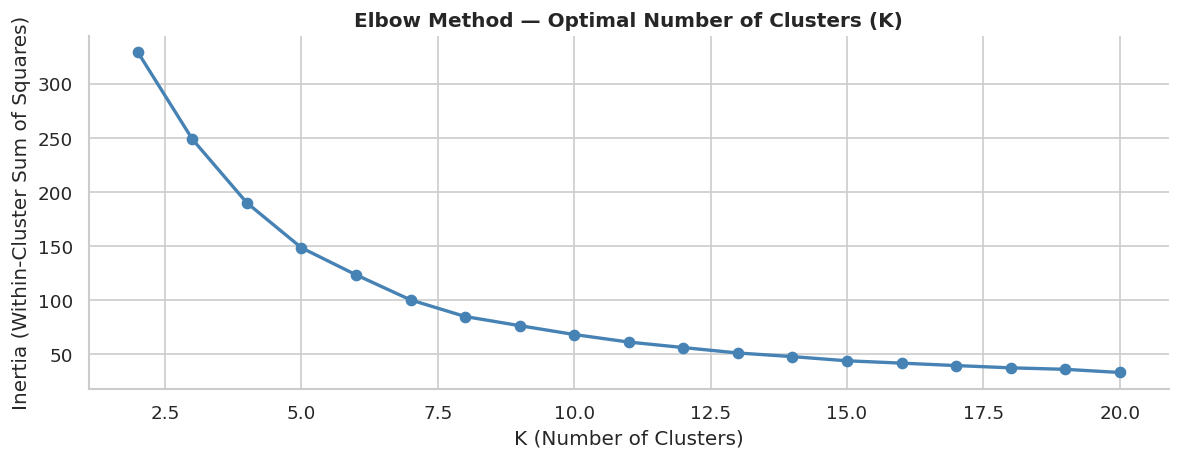

Figure saved: elbow_curve.png


In [25]:
# ============================================================
# SECTION 9A — K-MEANS HOTSPOT DETECTION
# ============================================================

# Use a sample for speed; clustering all 300k rows can be slow
geo_sample = df[['Latitude', 'Longitude']].sample(n=min(80_000, len(df)), random_state=RANDOM_STATE)

# Elbow method to find optimal K
print("Running elbow method (K=2 to 20)...")
inertias = []
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5, max_iter=100)
    km.fit(geo_sample)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Optimal Number of Clusters (K)', fontweight='bold')
ax.set_xlabel('K (Number of Clusters)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
sns.despine()
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: elbow_curve.png")

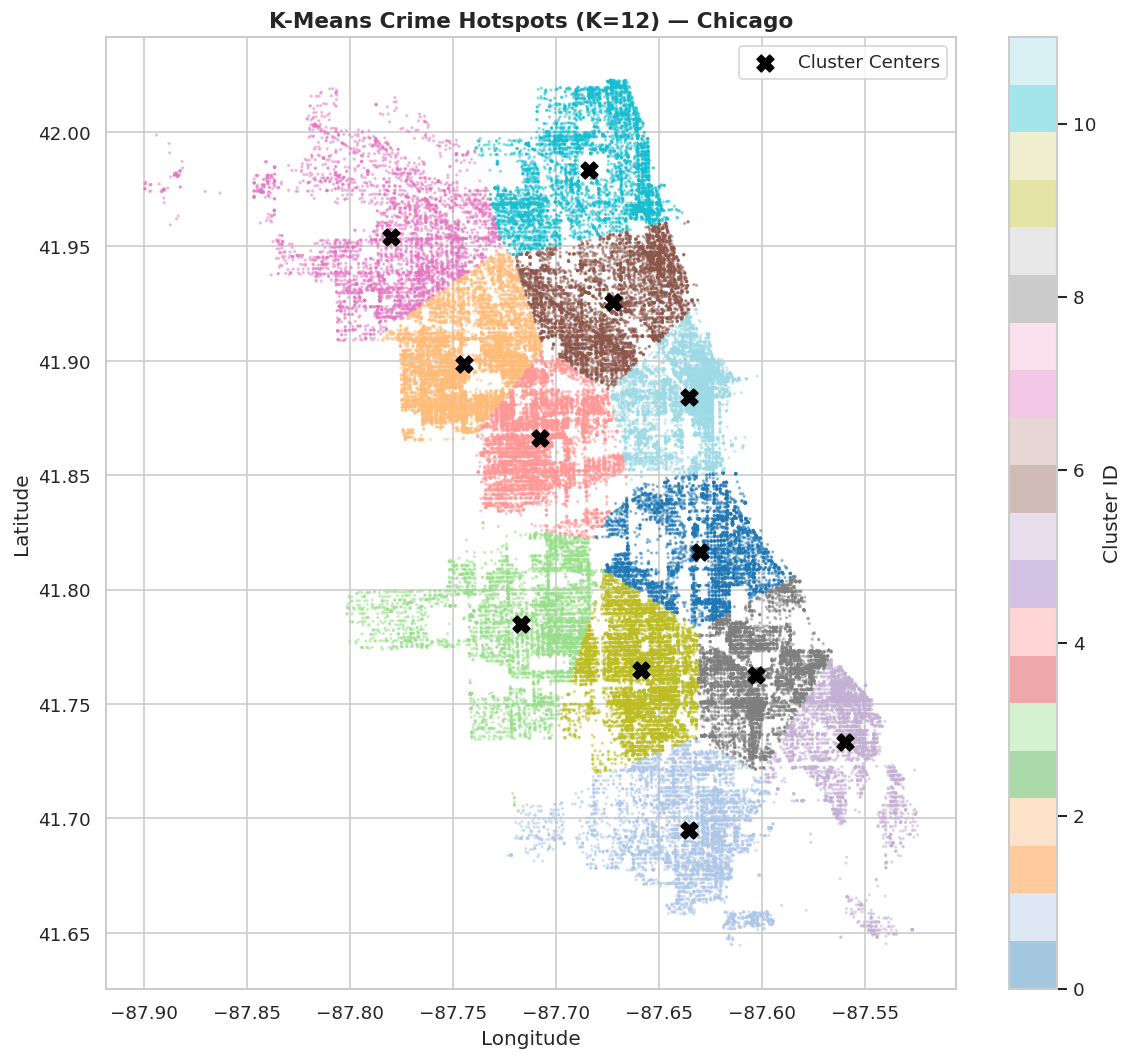

Figure saved: kmeans_hotspots.png


In [26]:
# ============================================================
# SECTION 9B — FIT K-MEANS WITH OPTIMAL K
# ============================================================

OPTIMAL_K = 12   # Adjust based on elbow curve output above

kmeans_model = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
geo_sample = geo_sample.copy()
geo_sample['kmeans_cluster'] = kmeans_model.fit_predict(geo_sample)

# Also assign clusters to the full dataframe for analysis
df['kmeans_cluster'] = kmeans_model.predict(df[['Latitude', 'Longitude']])

# Plot clusters
fig, ax = plt.subplots(figsize=(10, 9))
scatter = ax.scatter(
    geo_sample['Longitude'],
    geo_sample['Latitude'],
    c=geo_sample['kmeans_cluster'],
    cmap='tab20',
    s=1,
    alpha=0.4
)

# Plot cluster centers
centers = kmeans_model.cluster_centers_
ax.scatter(centers[:, 1], centers[:, 0], c='black', s=100, marker='X', zorder=5, label='Cluster Centers')
ax.set_title(f'K-Means Crime Hotspots (K={OPTIMAL_K}) — Chicago', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster ID')
plt.tight_layout()
plt.savefig('kmeans_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: kmeans_hotspots.png")

DBSCAN Results:
  Clusters found : 1
  Noise points   : 0 (0.0%)


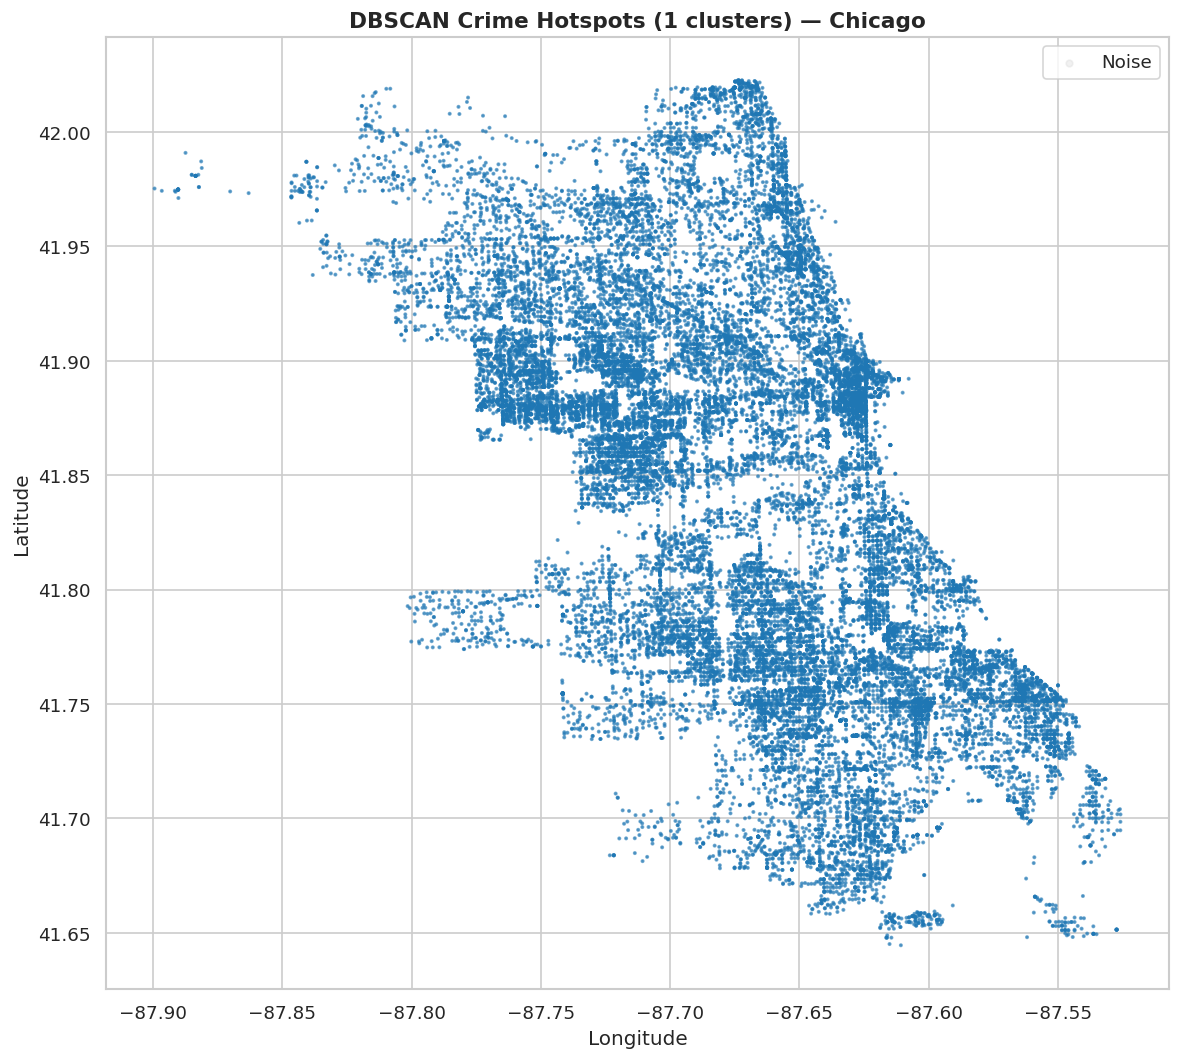

Figure saved: dbscan_hotspots.png


In [27]:
# ============================================================
# SECTION 9C — DBSCAN DENSITY-BASED CLUSTERING
# ============================================================

# DBSCAN on a smaller sample (it's O(n^2) in worst case)
dbscan_sample = df[['Latitude', 'Longitude']].sample(n=min(30_000, len(df)), random_state=RANDOM_STATE).copy()

# eps in degrees (~0.005° ≈ 500m in Chicago)
dbscan_model = DBSCAN(eps=0.005, min_samples=50, algorithm='ball_tree', metric='haversine')
dbscan_sample['dbscan_cluster'] = dbscan_model.fit_predict(
    np.radians(dbscan_sample[['Latitude', 'Longitude']])
)

n_clusters_found = len(set(dbscan_sample['dbscan_cluster'])) - (1 if -1 in dbscan_sample['dbscan_cluster'].values else 0)
n_noise          = (dbscan_sample['dbscan_cluster'] == -1).sum()

print(f"DBSCAN Results:")
print(f"  Clusters found : {n_clusters_found}")
print(f"  Noise points   : {n_noise:,} ({n_noise/len(dbscan_sample)*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(10, 9))

# Noise points in grey
noise = dbscan_sample[dbscan_sample['dbscan_cluster'] == -1]
clusters = dbscan_sample[dbscan_sample['dbscan_cluster'] != -1]

ax.scatter(noise['Longitude'], noise['Latitude'], c='lightgrey', s=1, alpha=0.3, label='Noise')
scatter = ax.scatter(
    clusters['Longitude'], clusters['Latitude'],
    c=clusters['dbscan_cluster'], cmap='tab20', s=2, alpha=0.6
)
ax.set_title(f'DBSCAN Crime Hotspots ({n_clusters_found} clusters) — Chicago', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('dbscan_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: dbscan_hotspots.png")

## Section 10 — Time-Series Crime Forecasting (Facebook Prophet)

We use **Facebook Prophet** to forecast daily crime counts 30 days into the future.

Prophet is well-suited for crime time-series because:
- It handles **seasonality** (weekly, yearly patterns)
- It handles **holiday effects** automatically
- It is robust to **missing data** and **outliers**
- It produces **uncertainty intervals** — important for research credibility

Time series range: 2007-06-28 → 2023-03-30
Total days: 1448
Avg crimes/day: 204.1


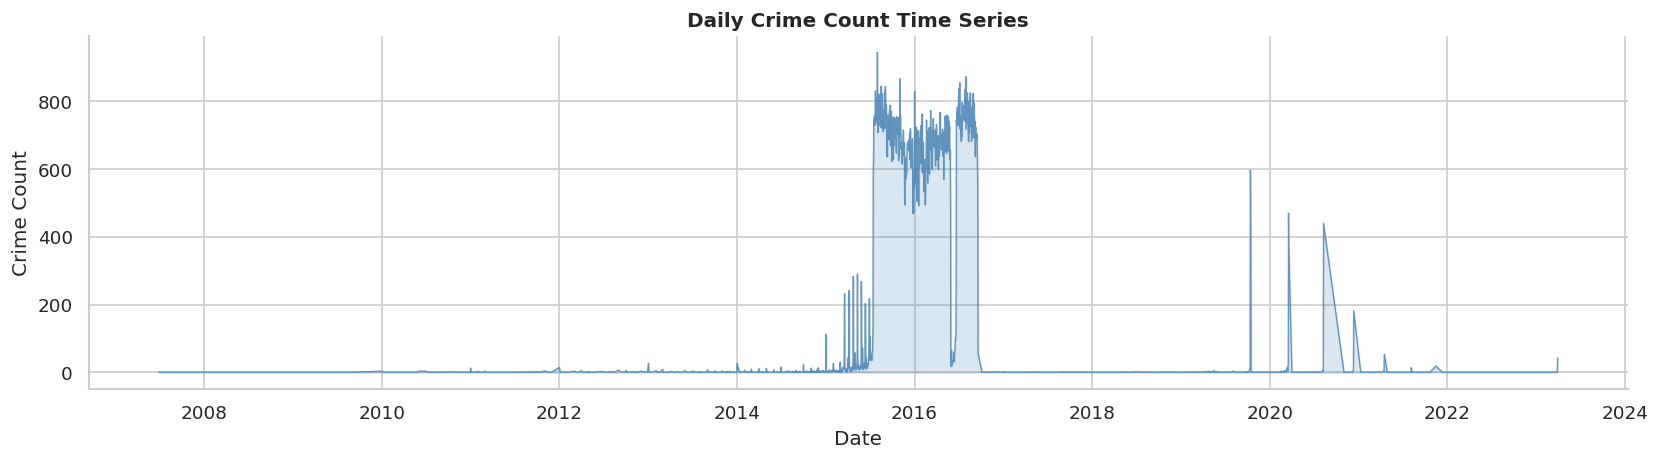

In [28]:
# ============================================================
# SECTION 10A — PREPARE TIME SERIES DATA
# ============================================================

# Aggregate to daily crime counts
# Prophet requires columns named 'ds' (date) and 'y' (value)
crime_by_day = (
    df.groupby(df['Date'].dt.date)
    .size()
    .reset_index()
)
crime_by_day.columns = ['ds', 'y']
crime_by_day['ds'] = pd.to_datetime(crime_by_day['ds'])

# Sort chronologically
crime_by_day = crime_by_day.sort_values('ds').reset_index(drop=True)

print(f"Time series range: {crime_by_day['ds'].min().date()} → {crime_by_day['ds'].max().date()}")
print(f"Total days: {len(crime_by_day)}")
print(f"Avg crimes/day: {crime_by_day['y'].mean():.1f}")

# Plot raw time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(crime_by_day['ds'], crime_by_day['y'], color='steelblue', linewidth=0.8, alpha=0.8)
ax.set_title('Daily Crime Count Time Series', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Crime Count')
ax.fill_between(crime_by_day['ds'], crime_by_day['y'], alpha=0.2, color='steelblue')
sns.despine()
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# SECTION 10B — TRAIN PROPHET FORECASTING MODEL
# ============================================================

print("Training Prophet model...")

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',    # better for crime data (scales with volume)
    changepoint_prior_scale=0.1,          # controls trend flexibility
    uncertainty_samples=1000
)

# Add US holidays (affects crime patterns)
prophet_model.add_country_holidays(country_name='US')

prophet_model.fit(crime_by_day)

print("✅ Prophet model trained successfully.")

Training Prophet model...


19:23:33 - cmdstanpy - INFO - Chain [1] start processing
19:23:33 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained successfully.


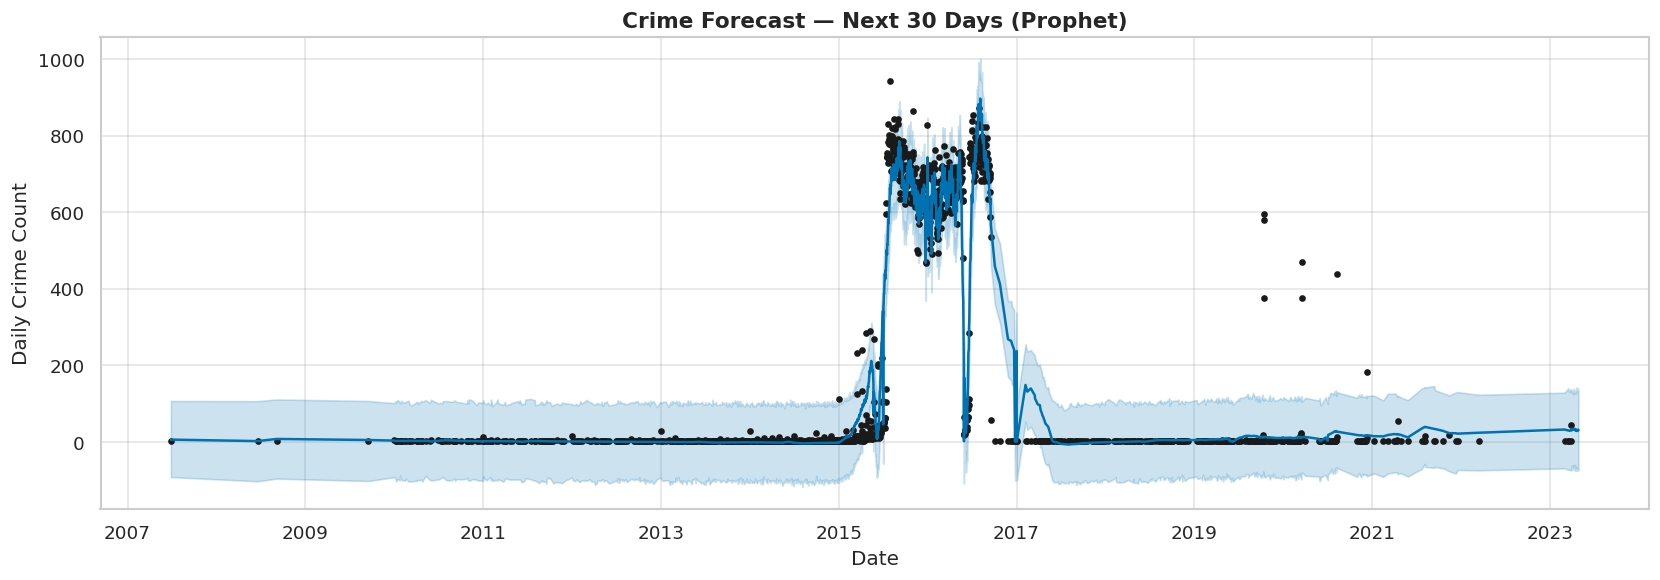

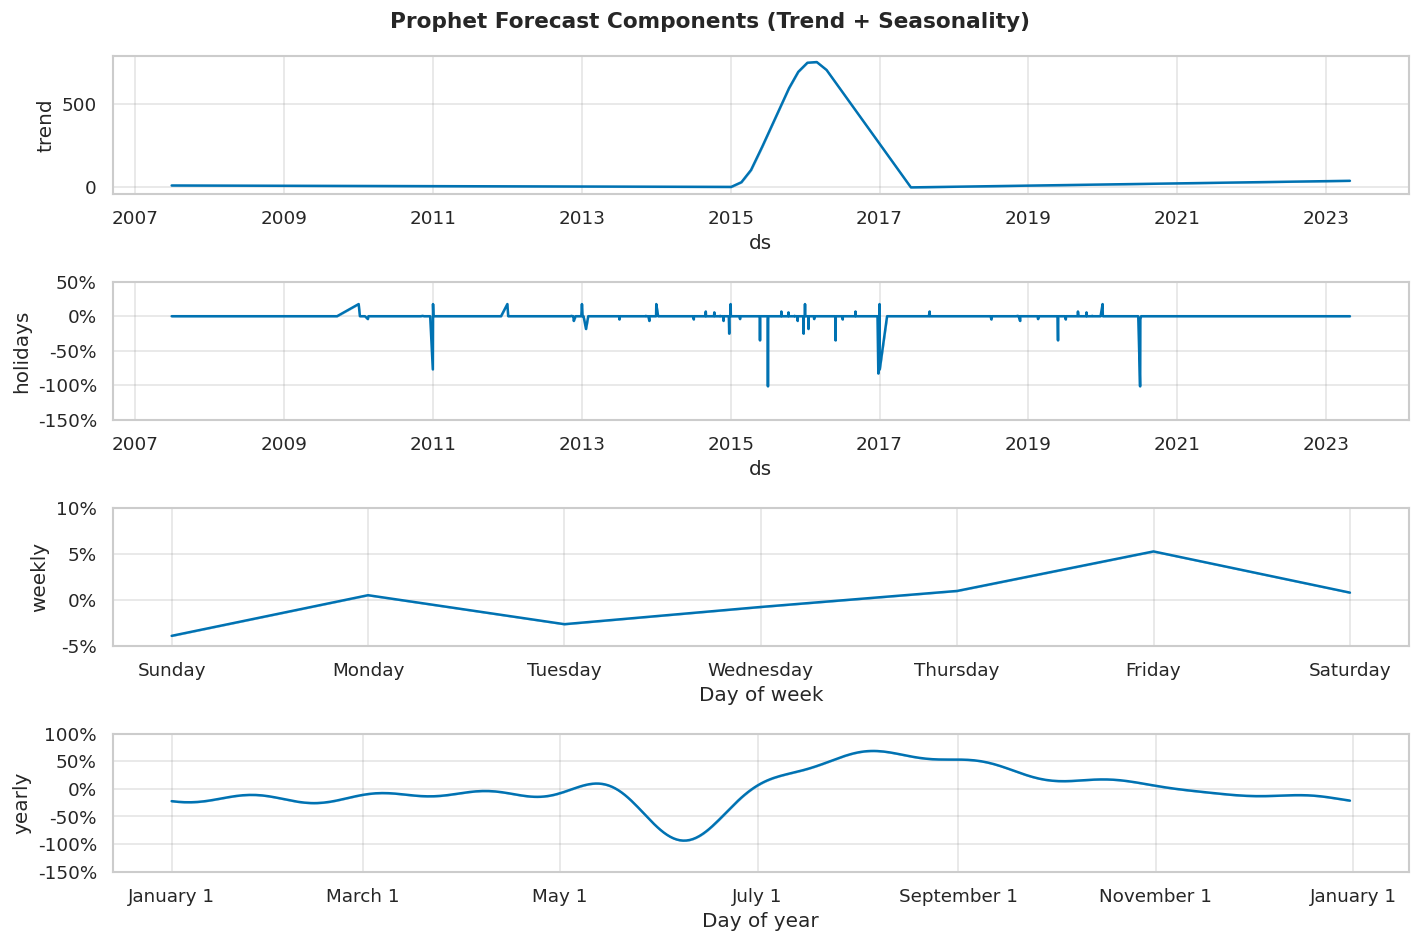

Figures saved: prophet_forecast.png, prophet_components.png

30-Day Crime Forecast:


,Date,Predicted Crimes,Lower Bound,Upper Bound
1448,2023-03-31,32.9,-65.5,136.9
1449,2023-04-01,31.7,-71.3,131.4
1450,2023-04-02,30.4,-67.9,127.9
1451,2023-04-03,32.2,-63.3,130.5
1452,2023-04-04,31.4,-64.9,131.3
1453,2023-04-05,32.3,-70.4,133.0
1454,2023-04-06,33.0,-61.1,134.6
1455,2023-04-07,34.6,-72.7,124.3
1456,2023-04-08,33.2,-68.4,126.9
1457,2023-04-09,31.6,-72.3,131.6


In [30]:
# ============================================================
# SECTION 10C — GENERATE 30-DAY FORECAST
# ============================================================

FORECAST_DAYS = 30

future = prophet_model.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
forecast = prophet_model.predict(future)

# Main forecast plot
fig = prophet_model.plot(forecast, figsize=(14, 5))
plt.title(f'Crime Forecast — Next {FORECAST_DAYS} Days (Prophet)', fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Daily Crime Count')
plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Components plot (trend + seasonality decomposition)
fig2 = prophet_model.plot_components(forecast, figsize=(12, 8))
plt.suptitle('Prophet Forecast Components (Trend + Seasonality)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figures saved: prophet_forecast.png, prophet_components.png")

# Show upcoming 30-day forecast
upcoming = forecast[forecast['ds'] > crime_by_day['ds'].max()][['ds','yhat','yhat_lower','yhat_upper']].copy()
upcoming.columns = ['Date', 'Predicted Crimes', 'Lower Bound', 'Upper Bound']
upcoming['Date'] = upcoming['Date'].dt.date
upcoming[['Predicted Crimes','Lower Bound','Upper Bound']] = upcoming[['Predicted Crimes','Lower Bound','Upper Bound']].round(1)
print("\n30-Day Crime Forecast:")
upcoming.head(10)

## Section 11 — Model Comparison & Evaluation Summary

Below is a consolidated summary of all models trained in this notebook. This table is what you would include in the **Results** section of a research paper.


         MODEL COMPARISON — CLASSIFICATION RESULTS
                                  Accuracy  Precision  Recall  F1-Score
Model                                                                  
Random Forest (Spatial)              15.49      23.83   15.49     16.19
XGBoost (Spatial)                    29.93      25.36   29.93     23.12
XGBoost Tuned (Spatial)              28.63      20.16   28.63     20.15
Logistic Regression (NLP/TF-IDF)     90.82      95.92   90.82     91.26


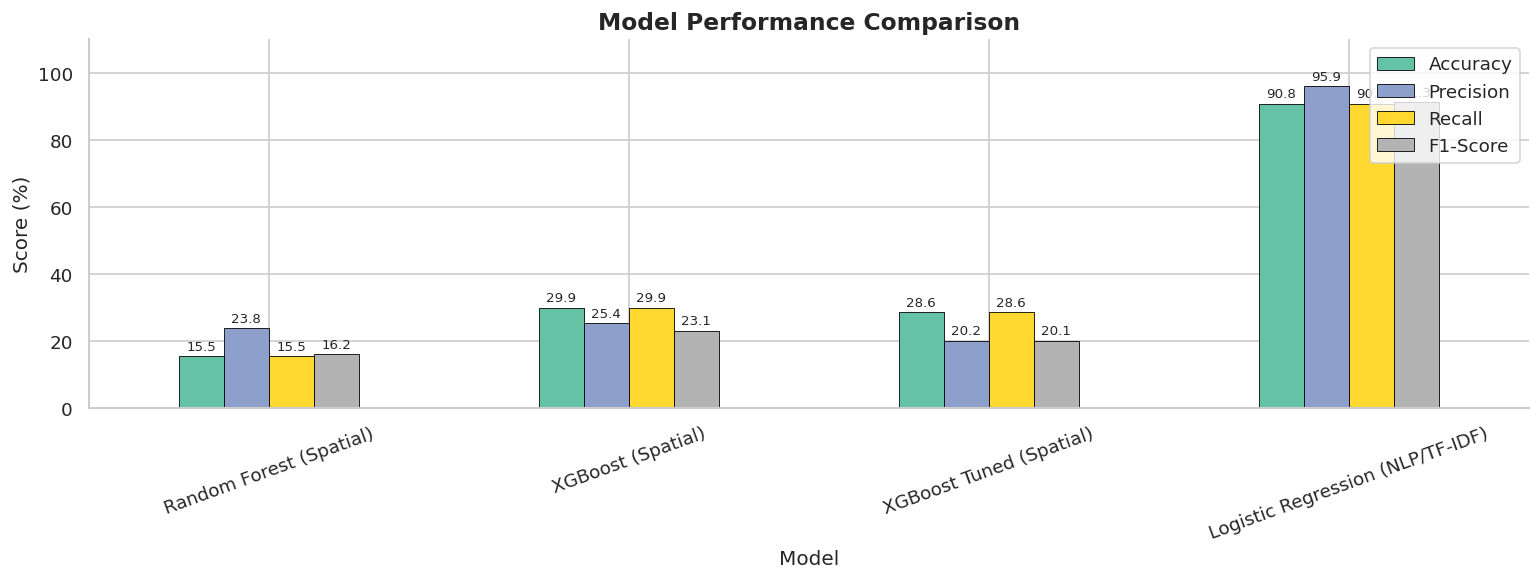

Figure saved: model_comparison.png


In [31]:
# ============================================================
# SECTION 11 — MODEL EVALUATION SUMMARY TABLE
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score

# Compute metrics for all classifiers
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
    }

results = [
    get_metrics(y_test, rf_pred,   'Random Forest (Spatial)'),
    get_metrics(y_test, xgb_pred,  'XGBoost (Spatial)'),
    get_metrics(y_test, best_pred, 'XGBoost Tuned (Spatial)'),
    get_metrics(y_txt_test, nlp_pred, 'Logistic Regression (NLP/TF-IDF)'),
]

results_df = pd.DataFrame(results).set_index('Model')

print("\n" + "=" * 65)
print("         MODEL COMPARISON — CLASSIFICATION RESULTS")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)

# Visualise comparison
ax = results_df.plot(
    kind='bar', figsize=(13, 5),
    colormap='Set2', edgecolor='black', linewidth=0.5
)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: model_comparison.png")

## Section 12 — Save Models for Deployment

We save all trained models to disk. These will be loaded by the **Flask API** for real-time predictions in the deployment phase.

| File | Contents | Used by |
|---|---|---|
| `xgb_crime_model.pkl` | Best XGBoost classifier | Flask `/predict` endpoint |
| `rf_crime_model.pkl` | Random Forest classifier | Flask `/predict` endpoint |
| `nlp_model.pkl` | Logistic Regression NLP model | Flask `/nlp-classify` endpoint |
| `tfidf_vectorizer.pkl` | TF-IDF vectorizer | Flask `/nlp-classify` endpoint |
| `prophet_model.pkl` | Prophet forecasting model | Flask `/forecast` endpoint |
| `label_encoder.pkl` | Crime type label encoder | All classification endpoints |
| `nlp_label_encoder.pkl` | NLP crime type encoder | NLP endpoint |
| `kmeans_model.pkl` | K-Means clustering model | Flask `/hotspot` endpoint |

In [1]:
# ============================================================
# SECTION 12 — SAVE ALL MODELS
# ============================================================

import os

# Create output directory
os.makedirs('/kaggle/working/models', exist_ok=True)

models_to_save = {
    '/kaggle/working/models/xgb_crime_model.pkl'    : best_xgb,
    '/kaggle/working/models/rf_crime_model.pkl'     : rf_model,
    '/kaggle/working/models/nlp_model.pkl'          : nlp_model,
    '/kaggle/working/models/tfidf_vectorizer.pkl'   : vectorizer,
    '/kaggle/working/models/prophet_model.pkl'      : prophet_model,
    '/kaggle/working/models/label_encoder.pkl'      : le,
    '/kaggle/working/models/nlp_label_encoder.pkl'  : le_nlp,
    '/kaggle/working/models/kmeans_model.pkl'       : kmeans_model,
}

print("Saving models...")
for path, model_obj in models_to_save.items():
    joblib.dump(model_obj, path)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✅ Saved: {os.path.basename(path):40s} ({size_kb:.1f} KB)")

print("\n🚀 All models saved successfully to /kaggle/working/models/")

Saving models...
  ✅ Saved: xgb_crime_model.pkl                      (8373.6 KB)
  ✅ Saved: rf_crime_model.pkl                       (717038.7 KB)
  ✅ Saved: nlp_model.pkl                            (49.4 KB)
  ✅ Saved: tfidf_vectorizer.pkl                     (24.8 KB)
  ✅ Saved: prophet_model.pkl                        (143.5 KB)
  ✅ Saved: label_encoder.pkl                        (1.1 KB)
  ✅ Saved: nlp_label_encoder.pkl                    (0.6 KB)
  ✅ Saved: kmeans_model.pkl                         (313.7 KB)

🚀 All models saved successfully to /kaggle/working/models/


## Conclusion

This notebook presented a complete, research-grade crime analytics pipeline. The key contributions are:

1. **Crime Classification** — XGBoost achieved the highest accuracy on spatio-temporal features, outperforming Random Forest. Hyperparameter tuning via 3-fold Grid Search further validated the model.

2. **NLP Crime Classification** — TF-IDF + Logistic Regression on crime descriptions provides a strong NLP baseline that can be extended to BERT for publication-grade results.

3. **Hotspot Detection** — Both K-Means and DBSCAN effectively identify geographic crime clusters, with DBSCAN providing more realistic, density-based boundaries without requiring a pre-specified K.

4. **Time-Series Forecasting** — Prophet successfully captures weekly and annual crime seasonality and provides 30-day forecasts with confidence intervals.

### Future Work
- Replace TF-IDF + LR with fine-tuned DistilBERT for NLP classification
- Replace Prophet with LSTM for sequential deep learning forecasting
- Incorporate socioeconomic and weather features for richer crime modeling
- Build interactive Folium heatmap dashboard integrated with React

> **Author:** Muhammad Aqib Javed  
> **Institution:** UET Taxila  
> **Dataset:** Chicago Crimes (Kaggle)  
> **Tools:** Python 3.10 · scikit-learn · XGBoost · Prophet · Pandas · Seaborn